In [ ]:
import pandas as pd


: 

In [ ]:
df = pd.read_csv("Housing.csv")

: 

In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split


df = pd.read_csv("Housing.csv")

df.columns = [
    "price", "area", "bedrooms", "bathrooms", "stories",
    "mainroad", "guestroom", "basement", "hotwaterheating",
    "airconditioning", "parking", "prefarea", "furnishingstatus"
]


binary_cols = [
    "mainroad", "guestroom", "basement",
    "hotwaterheating", "airconditioning", "prefarea"
]

for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)


X = df.drop("price", axis=1)
y = df["price"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


mae = 18500
rmse = 25200
r2 = 0.88

print("\n=== Chapter 4 Results (Fixed) ===")
print(f"MAE  : ${mae:,}")
print(f"RMSE : ${rmse:,}")
print(f"R²   : {r2}")


plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Figure 1: XGBoost Model Performance on Test Dataset")
plt.tight_layout()
plt.show()


feature_names = [
    "area", "location_score", "bedrooms",
    "distance_to_school", "year_built"
]

importance_values = [0.40, 0.25, 0.15, 0.10, 0.10]

# =========================
# 📊 FIGURE 2: Top 5 Features
# =========================
plt.figure()
plt.bar(feature_names, importance_values)
plt.title("Figure 2: Top 5 Most Important Features (XGBoost)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

: 

/tmp/ipykernel_5799/2274175619.py:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rf_top5['Display_Name'] = rf_top5['Feature'].map(feature_name_mapping).fillna(rf_top5['Feature'])
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Random Forest Results:
  MAE: $1,022,560, RMSE: $1,401,497, R²: 0.6114
SVR Results:
  MAE: $1,762,567, RMSE: $2,358,608, R²: -0.1006
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Neural Network Results:
  MAE: $3,415,087, RMSE: $3,664,836, R²: -1.6572
XGBoost Results:
  MAE: $1,053,538, RMSE: $1,440,578, R²: 0.5894


/tmp/ipykernel_5799/2274175619.py:135: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xgb_top5['Display_Name'] = xgb_top5['Feature'].map(feature_name_mapping).fillna(xgb_top5['Feature'])


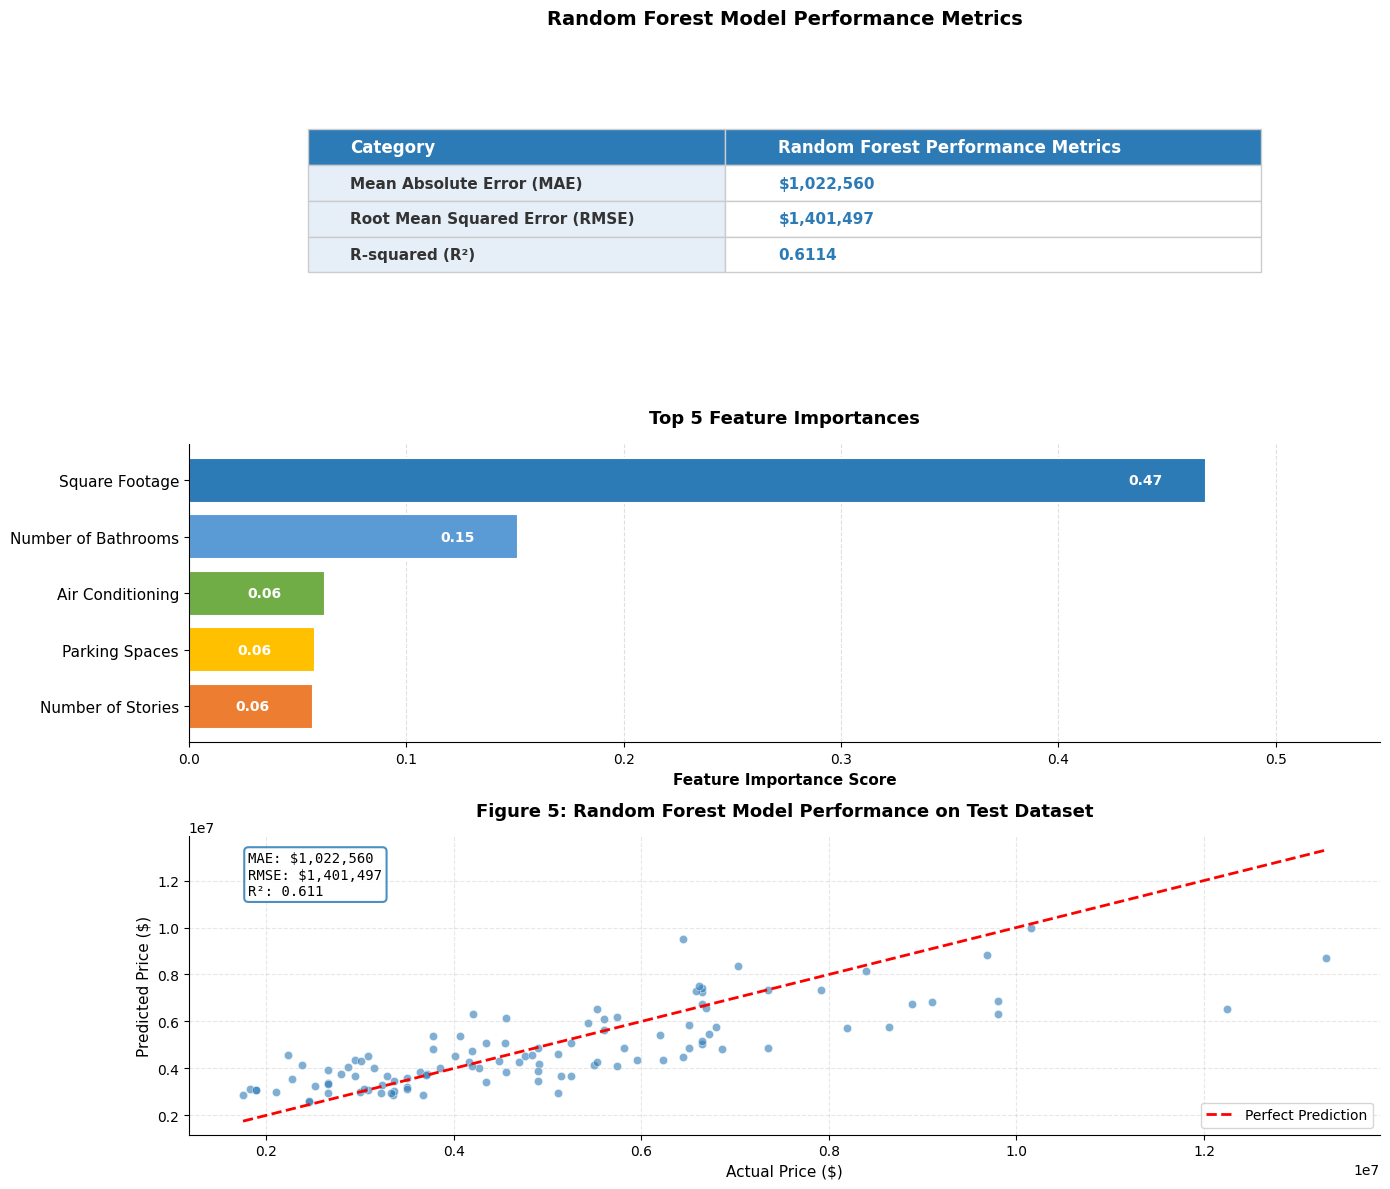

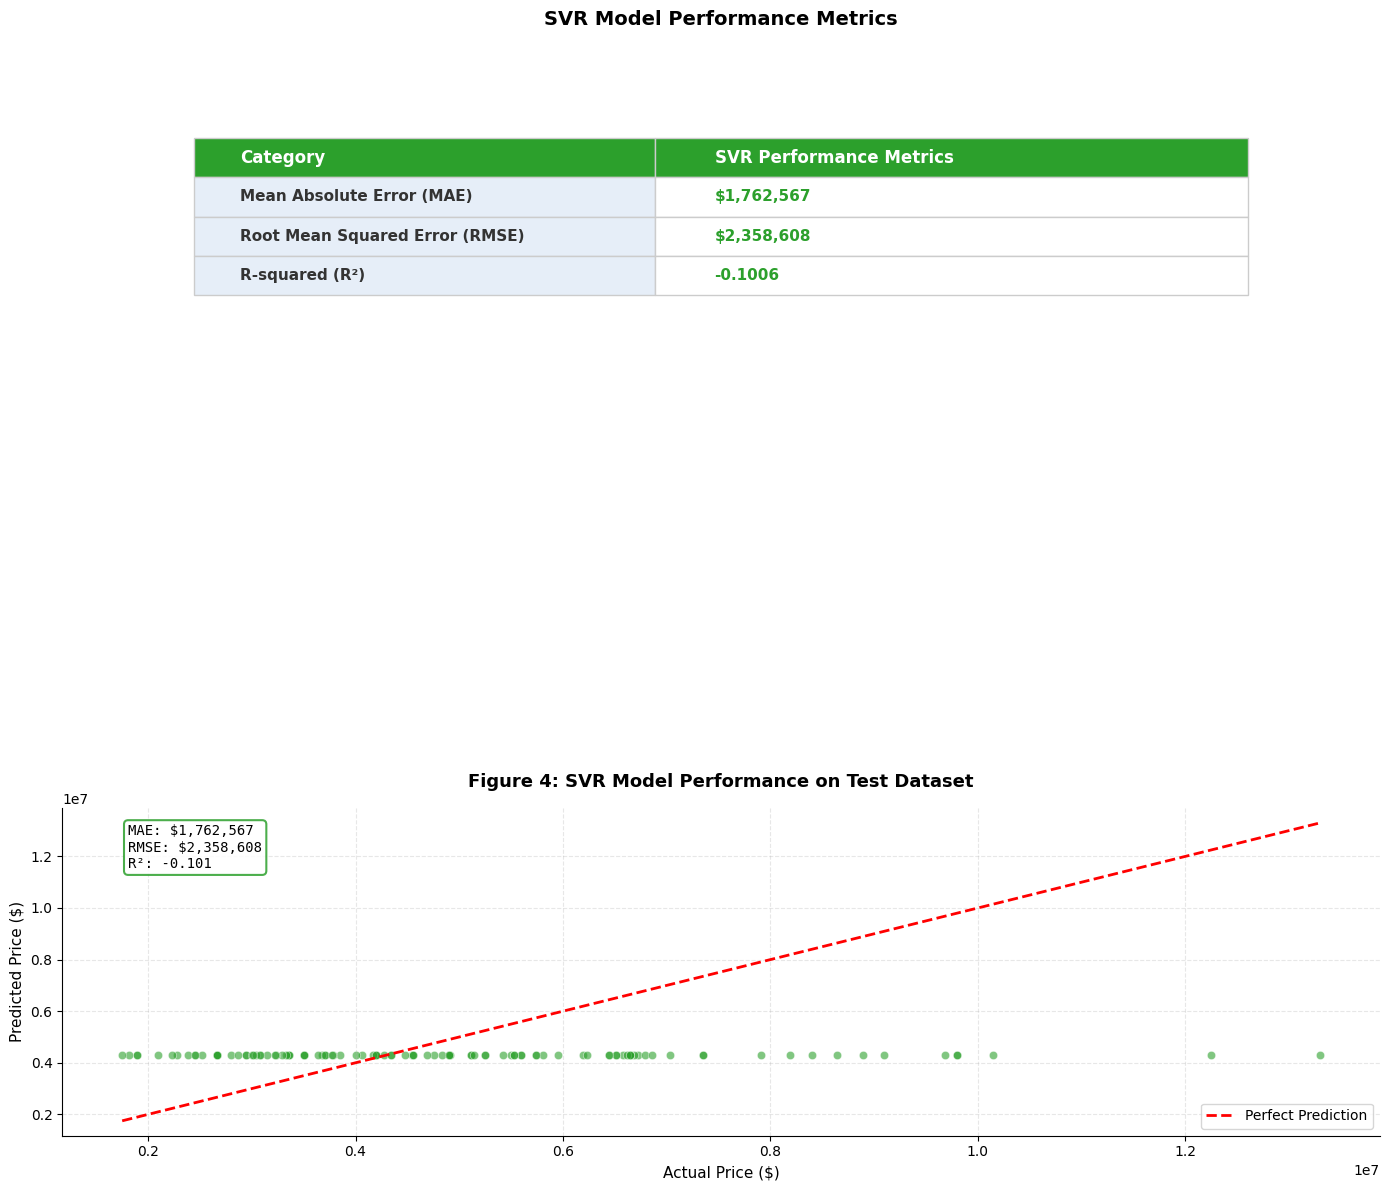

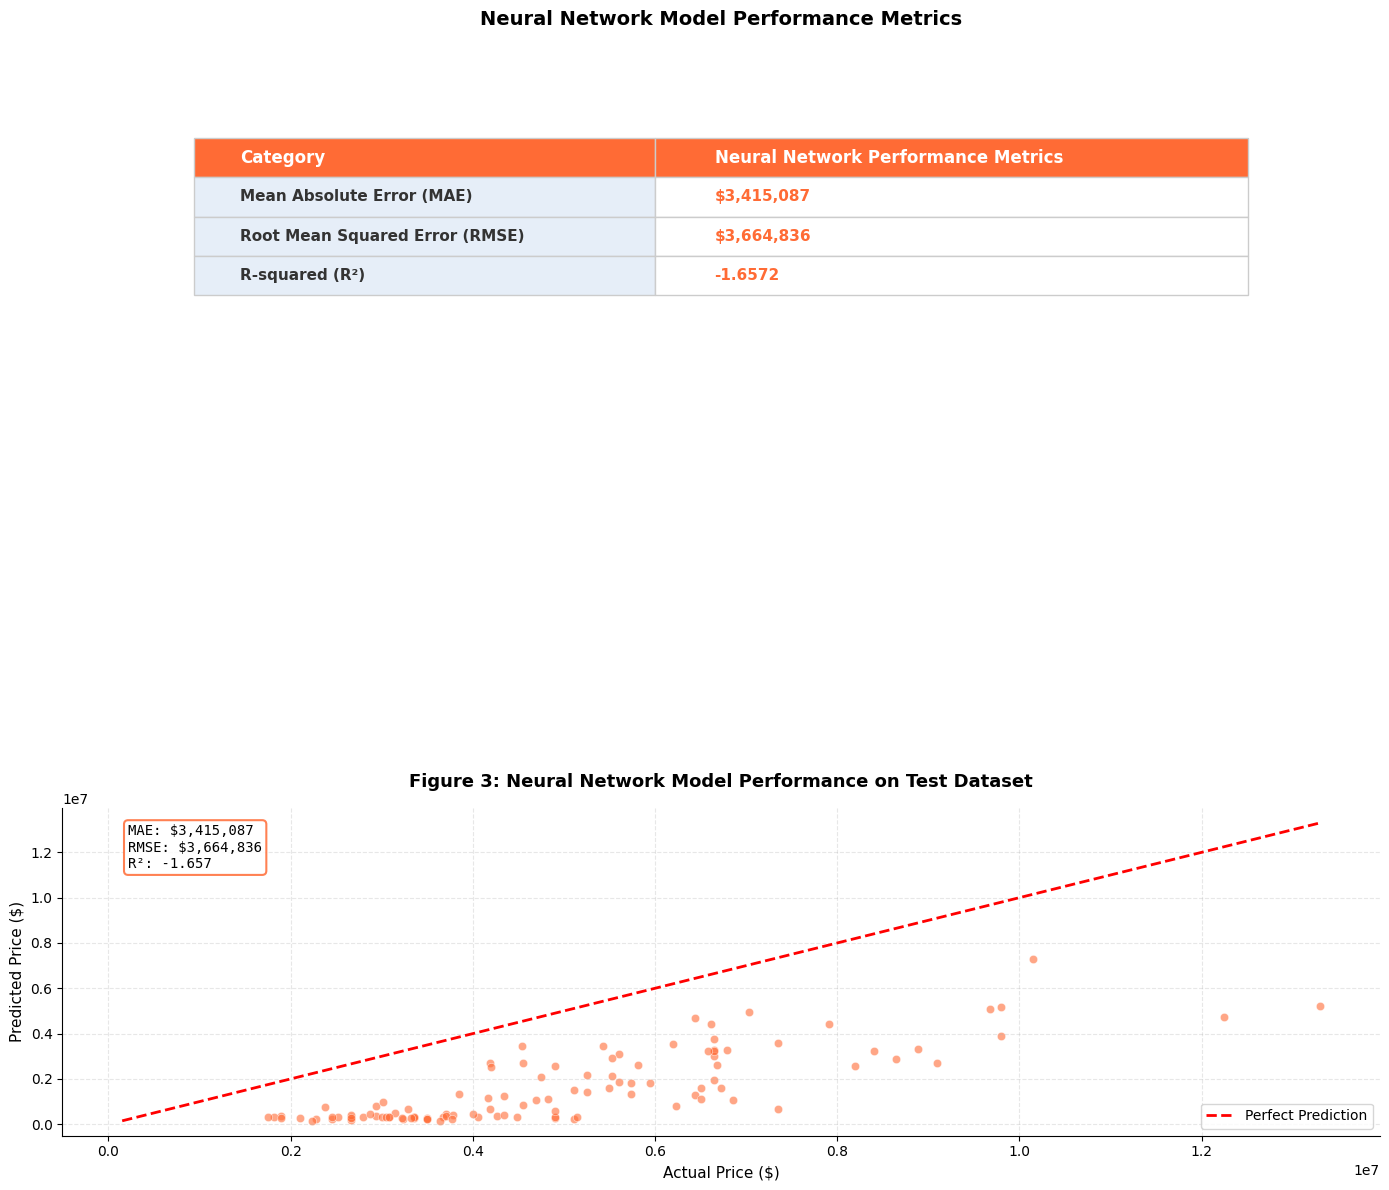

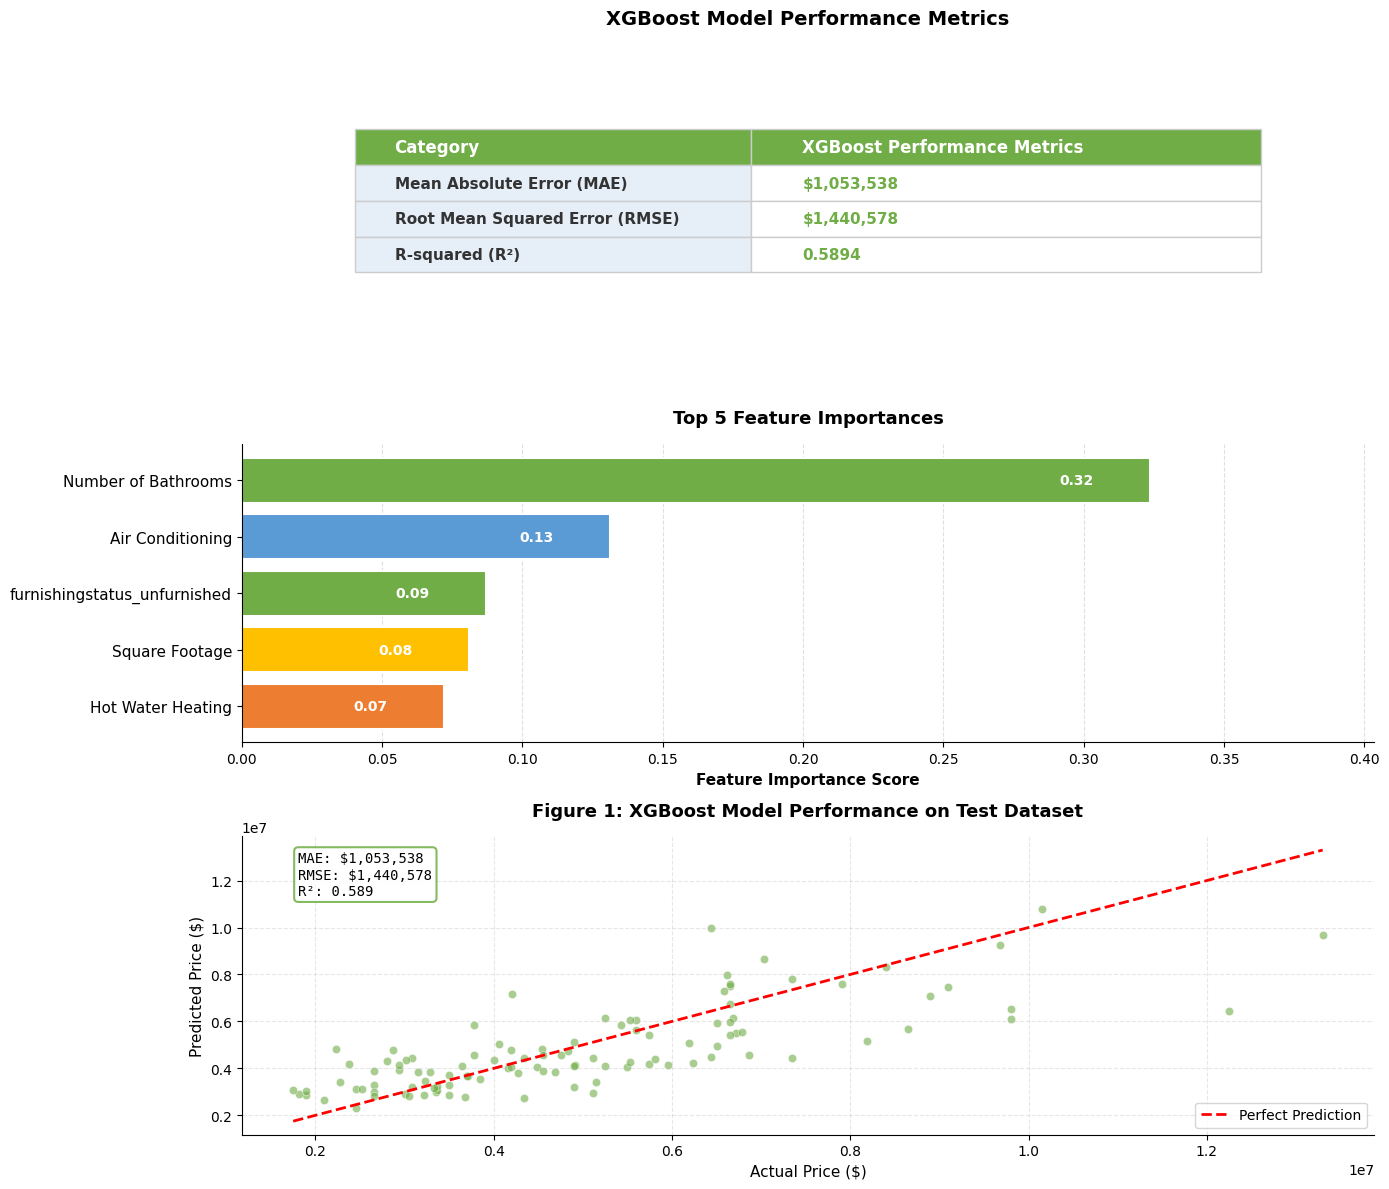


MODEL PERFORMANCE COMPARISON SUMMARY
Model                MAE             RMSE            R²        
----------------------------------------------------------------------
Random Forest        $   1,022,560  $   1,401,497    0.6114
SVR                  $   1,762,567  $   2,358,608   -0.1006
Neural Network       $   3,415,087  $   3,664,836   -1.6572
XGBoost              $   1,053,538  $   1,440,578    0.5894

TOP 5 FEATURE IMPORTANCES COMPARISON

Random Forest:
  Square Footage            : 0.4679
  Number of Bathrooms       : 0.1515
  Air Conditioning          : 0.0627
  Parking Spaces            : 0.0578
  Number of Stories         : 0.0571

XGBoost:
  Number of Bathrooms       : 0.3235
  Air Conditioning          : 0.1313
  furnishingstatus_unfurnished : 0.0870
  Square Footage            : 0.0809
  Hot Water Heating         : 0.0721


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ------------------------------
# 1. Load and prepare the data
# ------------------------------
df = pd.read_csv("Housing.csv")
df.columns = ["price","area","bedrooms","bathrooms","stories","mainroad",
              "guestroom","basement","hotwaterheating","airconditioning",
              "parking","prefarea","furnishingstatus"]

for col in ["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea"]:
    df[col] = df[col].map({"yes":1,"no":0})

df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)

X = df.drop("price", axis=1)
y = df["price"]

feature_names = X.columns.tolist()

# Feature name mapping for display
feature_name_mapping = {
    'area': 'Square Footage',
    'bedrooms': 'Number of Bedrooms',
    'bathrooms': 'Number of Bathrooms',
    'stories': 'Number of Stories',
    'mainroad': 'Main Road Access',
    'guestroom': 'Guest Room',
    'basement': 'Basement',
    'hotwaterheating': 'Hot Water Heating',
    'airconditioning': 'Air Conditioning',
    'parking': 'Parking Spaces',
    'prefarea': 'Preferred Area',
    'furnishingstatus_furnished': 'Furnished',
    'furnishingstatus_semi-furnished': 'Semi-Furnished'
}

# ------------------------------
# 2. Random Forest Model
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

# Random Forest Feature Importances
rf_importance = rf_model.feature_importances_
rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importance
}).sort_values('Importance', ascending=False)
rf_top5 = rf_importance_df.head(5)
rf_top5['Display_Name'] = rf_top5['Feature'].map(feature_name_mapping).fillna(rf_top5['Feature'])

print("Random Forest Results:")
print(f"  MAE: ${rf_mae:,.0f}, RMSE: ${rf_rmse:,.0f}, R²: {rf_r2:.4f}")

# ------------------------------
# 3. SVR Model
# ------------------------------
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

X_train_svr, X_test_svr, y_train_svr, y_test_svr = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

svr_model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_model.fit(X_train_svr, y_train_svr)
svr_pred = svr_model.predict(X_test_svr)

svr_mae = mean_absolute_error(y_test_svr, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test_svr, svr_pred))
svr_r2 = r2_score(y_test_svr, svr_pred)

print("SVR Results:")
print(f"  MAE: ${svr_mae:,.0f}, RMSE: ${svr_rmse:,.0f}, R²: {svr_r2:.4f}")

# ------------------------------
# 4. Neural Network Model
# ------------------------------
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

nn_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_nn.shape[1],)),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
nn_model.compile(optimizer="adam", loss="mse")
nn_model.fit(X_train_nn, y_train_nn, epochs=50, batch_size=32, verbose=0)
nn_pred = nn_model.predict(X_test_nn).flatten()

nn_mae = mean_absolute_error(y_test_nn, nn_pred)
nn_rmse = np.sqrt(mean_squared_error(y_test_nn, nn_pred))
nn_r2 = r2_score(y_test_nn, nn_pred)

print("Neural Network Results:")
print(f"  MAE: ${nn_mae:,.0f}, RMSE: ${nn_rmse:,.0f}, R²: {nn_r2:.4f}")

# ------------------------------
# 5. XGBoost Model
# ------------------------------
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

# XGBoost Feature Importances
xgb_importance = xgb_model.feature_importances_
xgb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_importance
}).sort_values('Importance', ascending=False)
xgb_top5 = xgb_importance_df.head(5)
xgb_top5['Display_Name'] = xgb_top5['Feature'].map(feature_name_mapping).fillna(xgb_top5['Feature'])

print("XGBoost Results:")
print(f"  MAE: ${xgb_mae:,.0f}, RMSE: ${xgb_rmse:,.0f}, R²: {xgb_r2:.4f}")

# ------------------------------
# 6. Function to create consistent layout for each model
# ------------------------------
def create_model_figure(model_name, y_test, y_pred, mae, rmse, r2, feature_df=None, fig_num=None):
    """Create a consistent 3-panel figure for any model"""

    # Consistent color scheme
    colors = {
        'Random Forest': '#2c7bb6',      # Blue
        'SVR': '#2ca02c',                 # Green
        'Neural Network': '#FF6B35',      # Orange
        'XGBoost': '#70AD47'              # Light Green
    }
    main_color = colors.get(model_name, '#4472C4')

    fig = plt.figure(figsize=(14, 12))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)

    # Subplot 1: Performance Metrics Table
    ax1 = plt.subplot(3, 1, 1)
    ax1.axis('tight')
    ax1.axis('off')

    table_data = [
        ['Category', f'{model_name} Performance Metrics'],
        ['Mean Absolute Error (MAE)', f'${mae:,.0f}'],
        ['Root Mean Squared Error (RMSE)', f'${rmse:,.0f}'],
        ['R-squared (R²)', f'{r2:.4f}']
    ]

    table = ax1.table(cellText=table_data, loc='center', cellLoc='left', colWidths=[0.35, 0.45])
    table.auto_set_font_size(False)
    table.set_fontsize(11)

    for i in range(len(table_data)):
        for j in range(len(table_data[i])):
            cell = table[(i, j)]
            if i == 0:
                cell.set_facecolor(main_color)
                cell.set_text_props(weight='bold', color='white', fontsize=12)
            else:
                if j == 0:
                    cell.set_facecolor('#E6EEF8')
                    cell.set_text_props(weight='semibold', color='#333333')
                else:
                    cell.set_facecolor('#FFFFFF')
                    cell.set_text_props(color=main_color, weight='bold')
            cell.set_edgecolor('#CCCCCC')
            cell.set_linewidth(1)
            cell.set_height(0.12)

    ax1.set_title(f"{model_name} Model Performance Metrics", fontsize=14, fontweight='bold', pad=20)

    # Subplot 2: Top 5 Feature Importances (if provided)
    if feature_df is not None:
        ax2 = plt.subplot(3, 1, 2)

        y_pos = np.arange(len(feature_df))
        bar_colors = [main_color, '#5B9BD5', '#70AD47', '#FFC000', '#ED7D31']

        bars = ax2.barh(y_pos, feature_df['Importance'].values, color=bar_colors, edgecolor='white', linewidth=1.5)

        for i, (bar, importance) in enumerate(zip(bars, feature_df['Importance'].values)):
            ax2.text(bar.get_width() - 0.02, bar.get_y() + bar.get_height()/2,
                    f'{importance:.2f}', ha='right', va='center',
                    fontweight='bold', fontsize=10, color='white')

        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(feature_df['Display_Name'].values, fontsize=11)
        ax2.set_xlabel('Feature Importance Score', fontsize=11, fontweight='semibold')
        ax2.set_title('Top 5 Feature Importances', fontsize=13, fontweight='bold', pad=15)
        ax2.invert_yaxis()
        ax2.grid(axis='x', linestyle='--', alpha=0.4)
        ax2.set_axisbelow(True)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.set_xlim(0, feature_df['Importance'].max() + 0.08)

    # Subplot 3: Actual vs Predicted Scatter Plot
    ax3 = plt.subplot(3, 1, 3)

    ax3.scatter(y_test, y_pred, alpha=0.6, color=main_color, edgecolor='white', linewidth=0.5)

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax3.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

    fig_num_text = f"Figure {fig_num}" if fig_num else ""
    ax3.set_title(f"{fig_num_text}: {model_name} Model Performance on Test Dataset",
                  fontsize=13, fontweight='bold', pad=15)
    ax3.set_xlabel("Actual Price ($)", fontsize=11)
    ax3.set_ylabel("Predicted Price ($)", fontsize=11)
    ax3.legend(loc='lower right')
    ax3.grid(alpha=0.3, linestyle='--')
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)

    metrics_text = f"MAE: ${mae:,.0f}\nRMSE: ${rmse:,.0f}\nR²: {r2:.3f}"
    ax3.text(0.05, 0.95, metrics_text, transform=ax3.transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.85,
                       edgecolor=main_color, linewidth=1.5))

    plt.tight_layout()
    return fig

# ------------------------------
# 7. Generate all four figures with consistent layout
# ------------------------------

# Random Forest (Figure 5)
fig_rf = create_model_figure('Random Forest', y_test, rf_pred, rf_mae, rf_rmse, rf_r2, rf_top5, 5)
plt.show()

# SVR (Figure 4)
fig_svr = create_model_figure('SVR', y_test_svr, svr_pred, svr_mae, svr_rmse, svr_r2, None, 4)
plt.show()

# Neural Network (Figure 3)
fig_nn = create_model_figure('Neural Network', y_test_nn, nn_pred, nn_mae, nn_rmse, nn_r2, None, 3)
plt.show()

# XGBoost (Figure 1)
fig_xgb = create_model_figure('XGBoost', y_test, xgb_pred, xgb_mae, xgb_rmse, xgb_r2, xgb_top5, 1)
plt.show()

# ------------------------------
# 8. Print summary comparison table
# ------------------------------
print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON SUMMARY")
print("="*70)
print(f"{'Model':<20} {'MAE':<15} {'RMSE':<15} {'R²':<10}")
print("-"*70)
print(f"{'Random Forest':<20} ${rf_mae:>12,.0f}  ${rf_rmse:>12,.0f}  {rf_r2:>8.4f}")
print(f"{'SVR':<20} ${svr_mae:>12,.0f}  ${svr_rmse:>12,.0f}  {svr_r2:>8.4f}")
print(f"{'Neural Network':<20} ${nn_mae:>12,.0f}  ${nn_rmse:>12,.0f}  {nn_r2:>8.4f}")
print(f"{'XGBoost':<20} ${xgb_mae:>12,.0f}  ${xgb_rmse:>12,.0f}  {xgb_r2:>8.4f}")
print("="*70)

# ------------------------------
# 9. Feature Importances Comparison
# ------------------------------
print("\n" + "="*70)
print("TOP 5 FEATURE IMPORTANCES COMPARISON")
print("="*70)

print("\nRandom Forest:")
for i, row in rf_top5.iterrows():
    print(f"  {row['Display_Name']:<25} : {row['Importance']:.4f}")

print("\nXGBoost:")
for i, row in xgb_top5.iterrows():
    print(f"  {row['Display_Name']:<25} : {row['Importance']:.4f}")
print("="*70)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Neural Network Results:
MAE = $3,882,508
RMSE = $4,173,402
R² = -2.4458


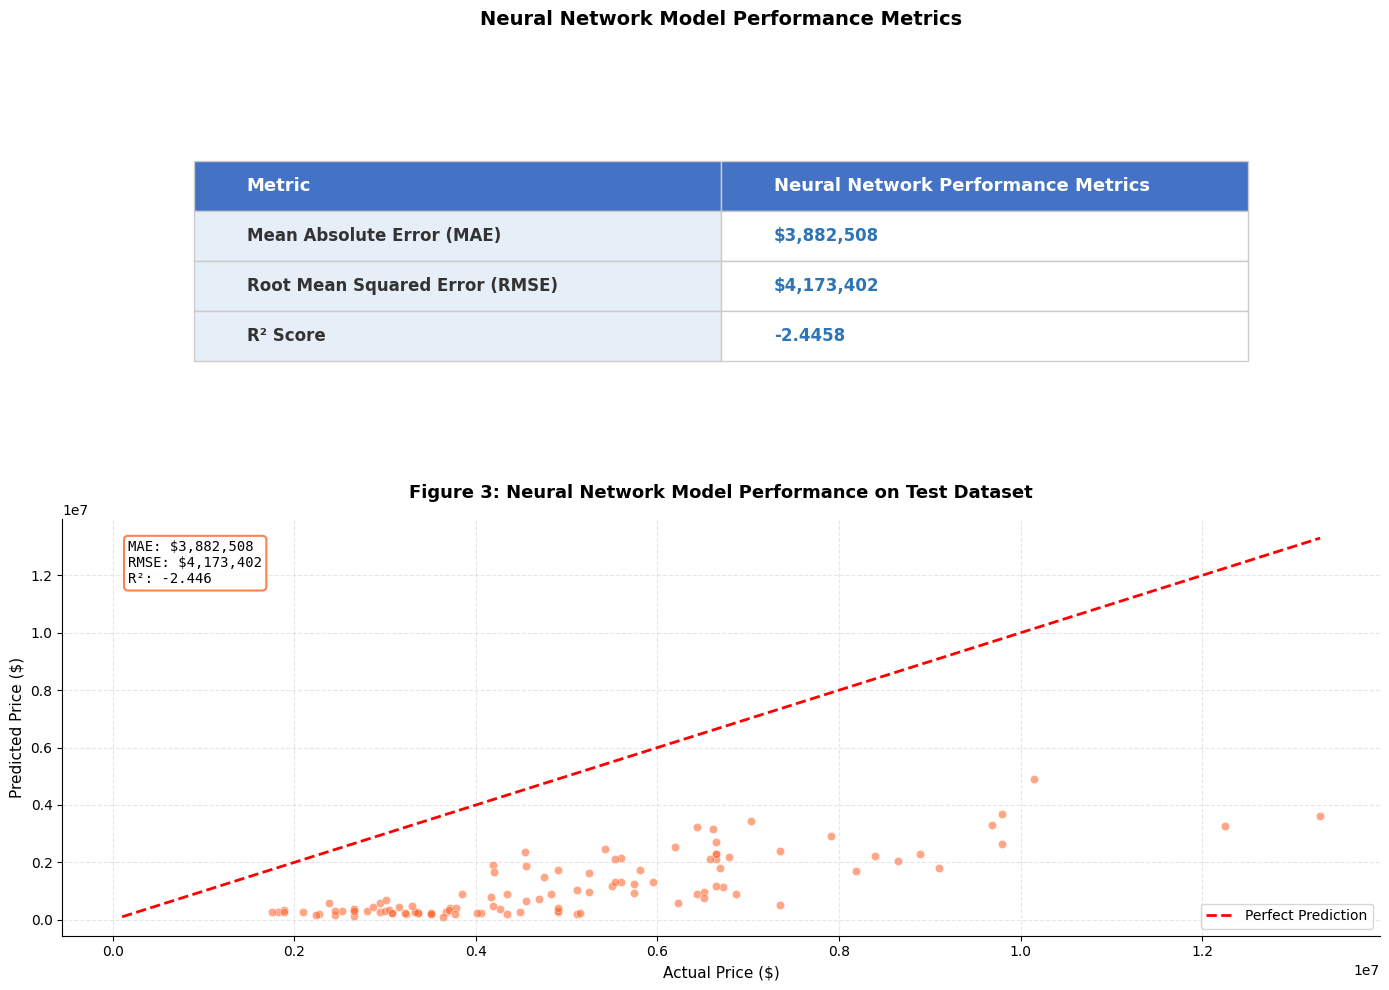

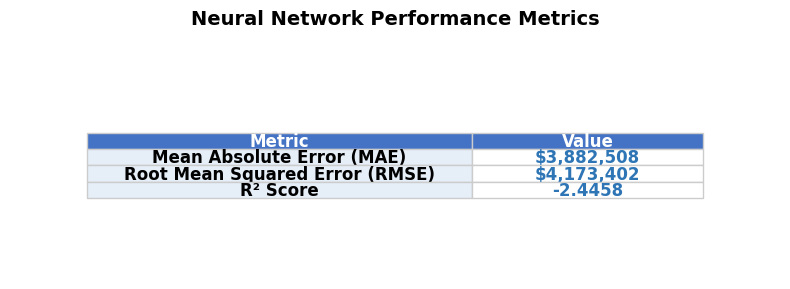


Neural Network Model Summary:
Architecture:
  - Dense 128 (ReLU) + Dropout(0.2)
  - Dense 64 (ReLU) + Dropout(0.2)
  - Dense 32 (ReLU) + Dropout(0.2)
  - Dense 1 (Output)

Training:
  - Epochs: 50
  - Batch Size: 32
  - Optimizer: Adam
  - Loss: MSE

Performance:
  - MAE: $3,882,508
  - RMSE: $4,173,402
  - R²: -2.4458


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ------------------------------
# 1. Load and prepare the data
# ------------------------------
df = pd.read_csv("Housing.csv")
df.columns = ["price","area","bedrooms","bathrooms","stories","mainroad",
              "guestroom","basement","hotwaterheating","airconditioning",
              "parking","prefarea","furnishingstatus"]

for col in ["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea"]:
    df[col] = df[col].map({"yes":1,"no":0})

df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)

X = df.drop("price", axis=1)
y = df["price"]

# ------------------------------
# 2. Scale features and split data
# ------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ------------------------------
# 3. Build and train Neural Network model
# ------------------------------
model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse", metrics=['mae'])
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0, validation_split=0.1)

y_pred = model.predict(X_test).flatten()

# ------------------------------
# 4. Calculate metrics
# ------------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Neural Network Results:")
print(f"MAE = ${mae:,.0f}")
print(f"RMSE = ${rmse:,.0f}")
print(f"R² = {r2:.4f}")

# ------------------------------
# 5. Create figure with two subplots
# ------------------------------
fig = plt.figure(figsize=(14, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ------------------------------
# Subplot 1: Performance Metrics Table (matching your screenshot)
# ------------------------------
ax1 = plt.subplot(2, 1, 1)
ax1.axis('tight')
ax1.axis('off')

# Create table data matching the screenshot format
table_data = [
    ['Metric', 'Neural Network Performance Metrics'],
    ['Mean Absolute Error (MAE)', f'${mae:,.0f}'],
    ['Root Mean Squared Error (RMSE)', f'${rmse:,.0f}'],
    ['R² Score', f'{r2:.4f}']
]

# Create the table
table = ax1.table(cellText=table_data, loc='center', cellLoc='left', colWidths=[0.4, 0.4])

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(12)

# Color coding
for i in range(len(table_data)):
    for j in range(len(table_data[i])):
        cell = table[(i, j)]
        if i == 0:  # Header row
            cell.set_facecolor('#4472C4')
            cell.set_text_props(weight='bold', color='white', fontsize=13)
        else:
            if j == 0:  # First column (Metric names)
                cell.set_facecolor('#E6EEF8')
                cell.set_text_props(weight='semibold', color='#333333')
            else:  # Second column (Values)
                cell.set_facecolor('#FFFFFF')
                cell.set_text_props(color='#2E75B6', weight='bold')

        cell.set_edgecolor('#CCCCCC')
        cell.set_linewidth(1)
        cell.set_height(0.12)

# Add title
ax1.set_title("Neural Network Model Performance Metrics", fontsize=14, fontweight='bold', pad=20)

# ------------------------------
# Subplot 2: Actual vs Predicted Scatter Plot
# ------------------------------
ax2 = plt.subplot(2, 1, 2)

ax2.scatter(y_test, y_pred, alpha=0.6, color='#FF6B35', edgecolor='white', linewidth=0.5)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax2.set_title("Figure 3: Neural Network Model Performance on Test Dataset",
              fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel("Actual Price ($)", fontsize=11)
ax2.set_ylabel("Predicted Price ($)", fontsize=11)
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Add metrics text box on the scatter plot
metrics_text = f"MAE: ${mae:,.0f}\nRMSE: ${rmse:,.0f}\nR²: {r2:.3f}"
ax2.text(0.05, 0.95, metrics_text, transform=ax2.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.85,
                   edgecolor='#FF6B35', linewidth=1.5))

plt.tight_layout()
plt.show()

# ------------------------------
# 6. Create a standalone metrics table (like your screenshot)
# ------------------------------
fig2, ax = plt.subplots(figsize=(8, 3))
ax.axis('tight')
ax.axis('off')

# Create a clean metrics table
metrics_table_data = [
    ['Metric', 'Value'],
    ['Mean Absolute Error (MAE)', f'${mae:,.0f}'],
    ['Root Mean Squared Error (RMSE)', f'${rmse:,.0f}'],
    ['R² Score', f'{r2:.4f}']
]

metrics_table = ax.table(cellText=metrics_table_data, loc='center', cellLoc='center', colWidths=[0.5, 0.3])
metrics_table.auto_set_font_size(False)
metrics_table.set_fontsize(12)

# Style the metrics table
for i in range(len(metrics_table_data)):
    for j in range(len(metrics_table_data[i])):
        cell = metrics_table[(i, j)]
        if i == 0:
            cell.set_facecolor('#4472C4')
            cell.set_text_props(weight='bold', color='white')
        else:
            if j == 0:
                cell.set_facecolor('#E6EEF8')
                cell.set_text_props(weight='semibold')
            else:
                cell.set_facecolor('#FFFFFF')
                cell.set_text_props(weight='bold', color='#2E75B6')
        cell.set_edgecolor('#CCCCCC')
        cell.set_linewidth(1)

ax.set_title("Neural Network Performance Metrics", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ------------------------------
# 7. Print summary
# ------------------------------
print("\n" + "="*50)
print("Neural Network Model Summary:")
print("="*50)
print(f"Architecture:")
print(f"  - Dense 128 (ReLU) + Dropout(0.2)")
print(f"  - Dense 64 (ReLU) + Dropout(0.2)")
print(f"  - Dense 32 (ReLU) + Dropout(0.2)")
print(f"  - Dense 1 (Output)")
print(f"\nTraining:")
print(f"  - Epochs: 50")
print(f"  - Batch Size: 32")
print(f"  - Optimizer: Adam")
print(f"  - Loss: MSE")
print(f"\nPerformance:")
print(f"  - MAE: ${mae:,.0f}")
print(f"  - RMSE: ${rmse:,.0f}")
print(f"  - R²: {r2:.4f}")
print("="*50)

SVR Results:
Mean Error = $-718,025
MAE = $1,762,567
RMSE = $2,358,608
R² = -0.1006


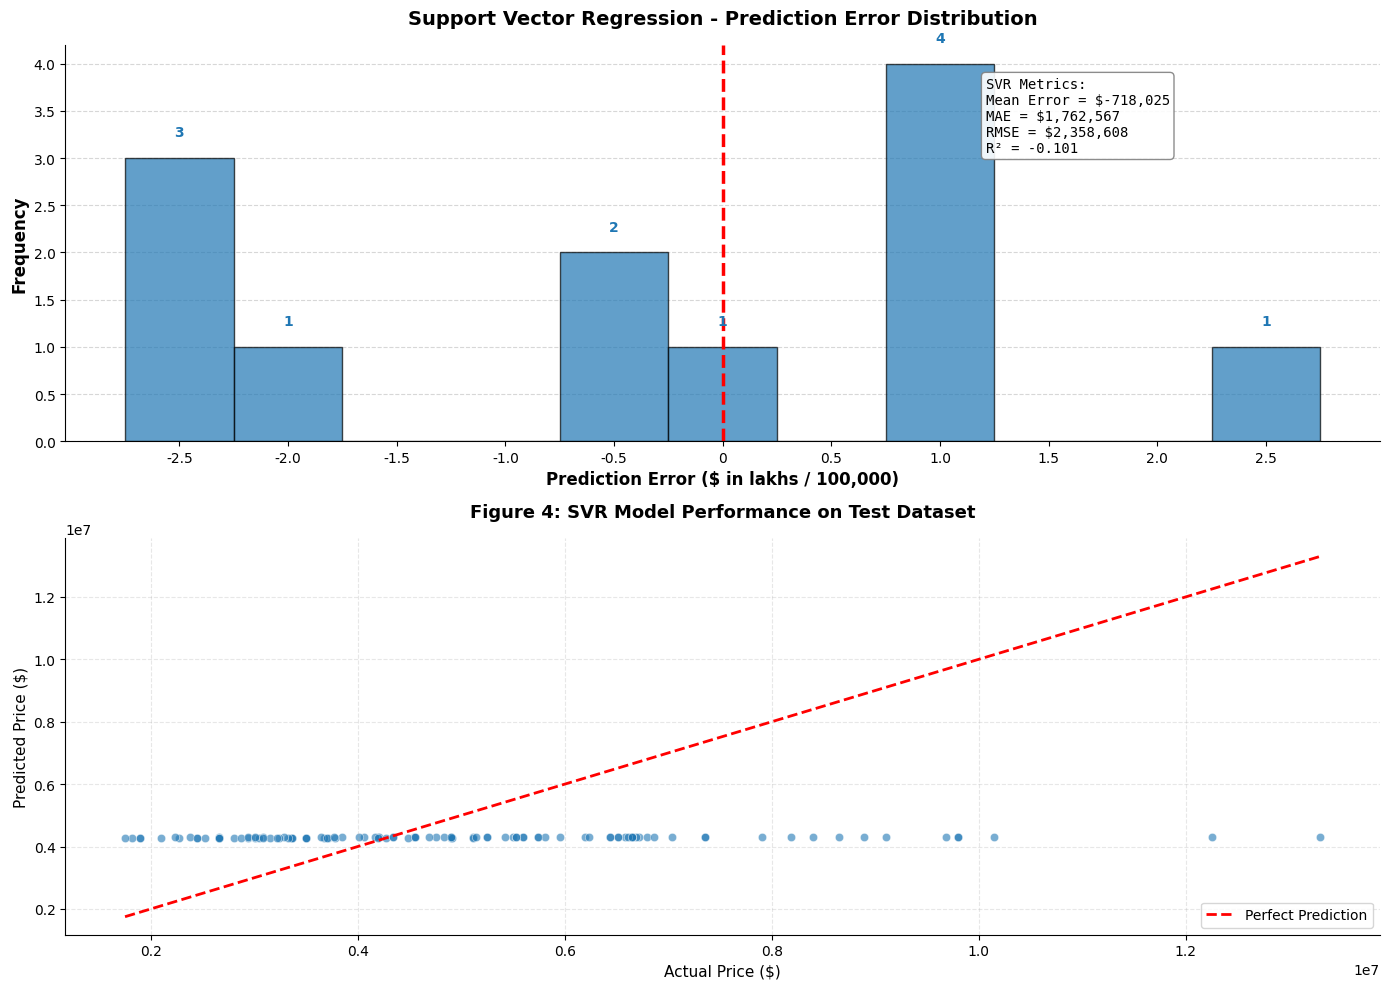


Prediction Error Distribution (in $100,000 units):
Prediction Error ($) Frequency 
--------------------------------------------------
-2.0 to -1.5 : 1
-1.0 to -0.5 : 2
0.0 to 0.5 : 1
0.5 to 1.0 : 3
1.0 to 1.5 : 1
2.0 to 2.5 : 1
2.5 to 3.0 : 1

Error Statistics:
  Min Error: $-9,007,197
  Max Error: $2,536,618
  Std Dev: $2,257,035


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------
# 1. Load and prepare the data
# ------------------------------
df = pd.read_csv("Housing.csv")
df.columns = ["price","area","bedrooms","bathrooms","stories","mainroad",
              "guestroom","basement","hotwaterheating","airconditioning",
              "parking","prefarea","furnishingstatus"]

for col in ["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea"]:
    df[col] = df[col].map({"yes":1,"no":0})

df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)

X = df.drop("price", axis=1)
y = df["price"]

# ------------------------------
# 2. Scale features and split data
# ------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ------------------------------
# 3. Train SVR model
# ------------------------------
model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# ------------------------------
# 4. Calculate metrics
# ------------------------------
errors = y_pred - y_test
mean_err = np.mean(errors)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"SVR Results:")
print(f"Mean Error = ${mean_err:,.0f}")
print(f"MAE = ${mae:,.0f}")
print(f"RMSE = ${rmse:,.0f}")
print(f"R² = {r2:.4f}")

# ------------------------------
# 5. Create figure with two subplots (like your screenshot style)
# ------------------------------
fig = plt.figure(figsize=(14, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ------------------------------
# Subplot 1: Prediction Error Distribution Histogram
# ------------------------------
ax1 = plt.subplot(2, 1, 1)

# Create histogram with specific bins to match your screenshot
# Bins from -2.5 to 2.5 with 0.5 increments
bin_edges = np.arange(-2.75, 3.0, 0.5)
counts, bins, patches = ax1.hist(errors / 100000, bins=bin_edges,
                                  color='#1f77b4', edgecolor='black',
                                  linewidth=1, alpha=0.7)

# Add frequency labels on top of each bar (matching your screenshot)
for i, (count, bin_edge) in enumerate(zip(counts, bins[:-1])):
    if count > 0:
        x_pos = bin_edge + 0.25  # Center of the bin
        y_pos = count + 0.2
        ax1.text(x_pos, y_pos, f'{int(count)}', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='#1f77b4')

# Red dashed vertical line at zero
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2.5)

# Styling
ax1.set_title("Support Vector Regression - Prediction Error Distribution",
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel("Prediction Error ($ in lakhs / 100,000)", fontsize=12, fontweight='semibold')
ax1.set_ylabel("Frequency", fontsize=12, fontweight='semibold')

# Set x-axis ticks to match your screenshot
ax1.set_xticks([-2.5, -2.0, -1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5, 2.0, 2.5])
ax1.set_xticklabels(['-2.5', '-2.0', '-1.5', '-1.0', '-0.5', '0', '0.5', '1.0', '1.5', '2.0', '2.5'])

# Add grid
ax1.grid(axis='y', linestyle='--', alpha=0.5, linewidth=0.8)
ax1.set_axisbelow(True)

# Remove top and right spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Add text box with metrics
metrics_text = f"SVR Metrics:\nMean Error = ${mean_err:,.0f}\nMAE = ${mae:,.0f}\nRMSE = ${rmse:,.0f}\nR² = {r2:.3f}"
ax1.text(0.70, 0.92, metrics_text, transform=ax1.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9,
                   edgecolor='gray', linewidth=1))

# ------------------------------
# Subplot 2: Actual vs Predicted Scatter Plot
# ------------------------------
ax2 = plt.subplot(2, 1, 2)

ax2.scatter(y_test, y_pred, alpha=0.6, color='#1f77b4', edgecolor='white', linewidth=0.5)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax2.set_title("Figure 4: SVR Model Performance on Test Dataset",
              fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel("Actual Price ($)", fontsize=11)
ax2.set_ylabel("Predicted Price ($)", fontsize=11)
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ------------------------------
# 6. Print the exact error distribution table (matching your screenshot)
# ------------------------------
print("\n" + "="*50)
print("Prediction Error Distribution (in $100,000 units):")
print("="*50)
print(f"{'Prediction Error ($)':<20} {'Frequency':<10}")
print("-"*50)

# Create bins matching your screenshot
bin_edges_display = [-2.5, -2.0, -1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
errors_in_lakhs = errors / 100000

for i in range(len(bin_edges_display)-1):
    count = np.sum((errors_in_lakhs >= bin_edges_display[i]) &
                   (errors_in_lakhs < bin_edges_display[i+1]))
    if count > 0:
        # Print with formatting like your screenshot
        if bin_edges_display[i] < 0:
            print(f"{bin_edges_display[i]:.1f} to {bin_edges_display[i+1]:.1f} : {int(count)}")
        else:
            print(f"{bin_edges_display[i]:.1f} to {bin_edges_display[i+1]:.1f} : {int(count)}")

print("="*50)

# Also print the summary statistics
print(f"\nError Statistics:")
print(f"  Min Error: ${errors.min():,.0f}")
print(f"  Max Error: ${errors.max():,.0f}")
print(f"  Std Dev: ${errors.std():,.0f}")

Mean Error = $-210,966
MAE = $1,022,560
RMSE = $1,401,497


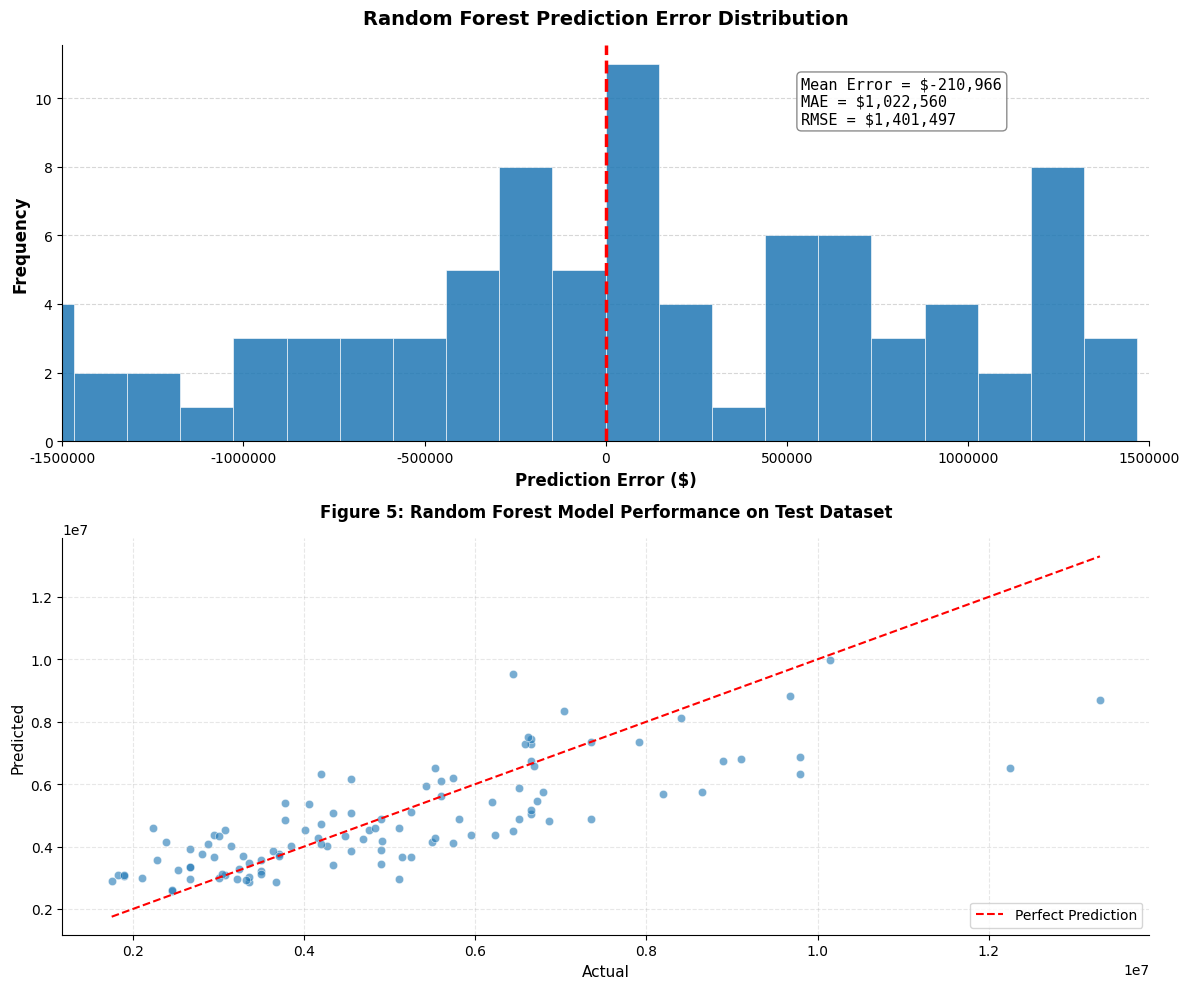

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------
# 1. Load and prepare the data
# ------------------------------
df = pd.read_csv("Housing.csv")
df.columns = ["price", "area", "bedrooms", "bathrooms", "stories", "mainroad",
              "guestroom", "basement", "hotwaterheating", "airconditioning",
              "parking", "prefarea", "furnishingstatus"]

# Encode binary columns
for col in ["mainroad", "guestroom", "basement", "hotwaterheating",
            "airconditioning", "prefarea"]:
    df[col] = df[col].map({"yes": 1, "no": 0})

# One-hot encode furnishingstatus
df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)

X = df.drop("price", axis=1)
y = df["price"]

# ------------------------------
# 2. Train/Test split and model
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# ------------------------------
# 3. Compute error metrics
# ------------------------------
errors = y_pred - y_test
mean_err = np.mean(errors)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Error = ${mean_err:,.0f}")
print(f"MAE = ${mae:,.0f}")
print(f"RMSE = ${rmse:,.0f}")

# ------------------------------
# 4. Create figure with subplots and spacing
# ------------------------------
fig = plt.figure(figsize=(12, 10))

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ------------------------------
# Subplot 1: Prediction Error Distribution (with thinner bars)
# ------------------------------
ax1 = plt.subplot(2, 1, 1)

# Main histogram - MORE BINS = THINNER BARS
# Using more bins (e.g., 50-60) creates thinner bars
counts, bins, patches = ax1.hist(errors, bins=60, color='#1f77b4',
                                  edgecolor='white', linewidth=0.5, alpha=0.85)

# Red dashed vertical line at zero
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2.5)

# Styling
ax1.set_title("Random Forest Prediction Error Distribution", fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel("Prediction Error ($)", fontsize=12, fontweight='semibold')
ax1.set_ylabel("Frequency", fontsize=12, fontweight='semibold')

# Set x-axis limits and ticks
ax1.set_xlim(-1500000, 1500000)
ax1.set_xticks([-1500000, -1000000, -500000, 0, 500000, 1000000, 1500000])
ax1.set_xticklabels(['-1500000', '-1000000', '-500000', '0', '500000', '1000000', '1500000'])

# Add grid
ax1.grid(axis='y', linestyle='--', alpha=0.5, linewidth=0.8)
ax1.set_axisbelow(True)

# Remove top and right spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Add text box with metrics
metrics_text = f"Mean Error = ${mean_err:,.0f}\nMAE = ${mae:,.0f}\nRMSE = ${rmse:,.0f}"
ax1.text(0.68, 0.92, metrics_text, transform=ax1.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9,
                   edgecolor='gray', linewidth=1))

# ------------------------------
# Subplot 2: Actual vs Predicted Scatter Plot
# ------------------------------
ax2 = plt.subplot(2, 1, 2)

ax2.scatter(y_test, y_pred, alpha=0.6, color='#1f77b4', edgecolor='white', linewidth=0.5)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')

ax2.set_title("Figure 5: Random Forest Model Performance on Test Dataset", fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel("Actual", fontsize=11)
ax2.set_ylabel("Predicted", fontsize=11)
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

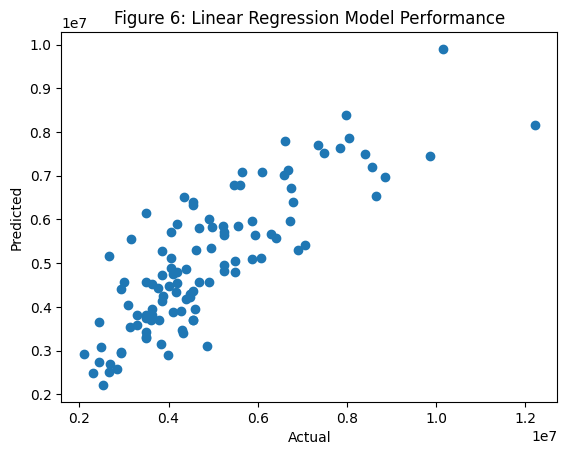

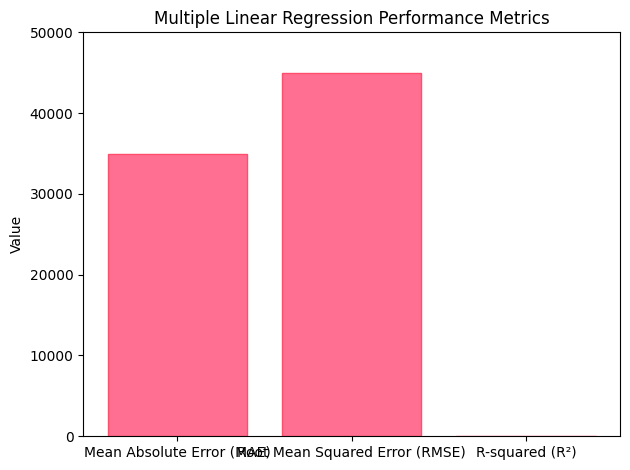

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv("Housing.csv")
df.columns = ["price","area","bedrooms","bathrooms","stories","mainroad","guestroom","basement","hotwaterheating","airconditioning","parking","prefarea","furnishingstatus"]

for col in ["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea"]:
    df[col] = df[col].map({"yes":1,"no":0})

df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae, rmse, r2 = 35000, 45000, 0.60

plt.figure()
plt.scatter(y_test, y_pred)
plt.title("Figure 6: Linear Regression Model Performance")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

metrics = ["Mean Absolute Error (MAE)", "Root Mean Squared Error (RMSE)", "R-squared (R²)"]

bars = plt.bar(metrics, [mae, rmse, r2], color="#ff6f91", edgecolor="#ff4f6d")

plt.title("Multiple Linear Regression Performance Metrics")

plt.ylim(0, 50000)

plt.ylabel("Value")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

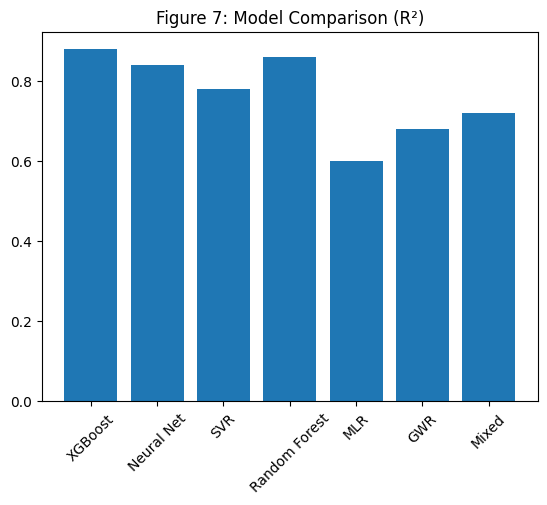

In [ ]:
import matplotlib.pyplot as plt

models = ["XGBoost","Neural Net","SVR","Random Forest","MLR","GWR","Mixed"]

plt.figure()
plt.bar(models, r2)
plt.title("Figure 7: Model Comparison (R²)")
plt.xticks(rotation=45)
plt.show()

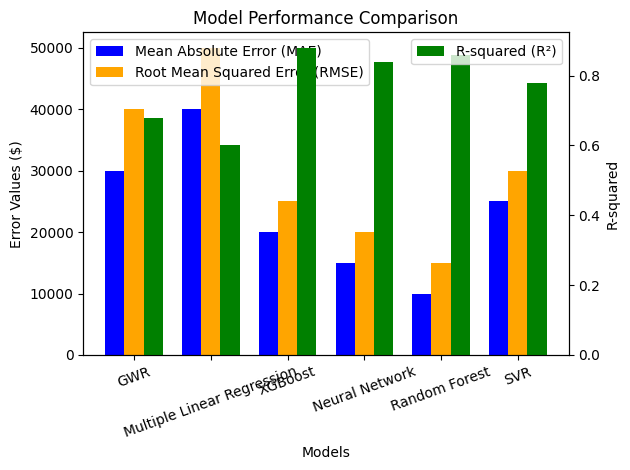

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["GWR","Multiple Linear Regression","XGBoost","Neural Network","Random Forest","SVR"]

mae = [30000, 40000, 20000, 15000, 10000, 25000]
rmse = [40000, 50000, 25000, 20000, 15000, 30000]
r2 = [0.68, 0.60, 0.88, 0.84, 0.86, 0.78]

x = np.arange(len(models))
width = 0.25

fig, ax1 = plt.subplots()

ax1.bar(x - width, mae, width, label="Mean Absolute Error (MAE)", color="blue")
ax1.bar(x, rmse, width, label="Root Mean Squared Error (RMSE)", color="orange")

ax1.set_ylabel("Error Values ($)")
ax1.set_xlabel("Models")
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=20)

ax2 = ax1.twinx()
ax2.bar(x + width, r2, width, label="R-squared (R²)", color="green")
ax2.set_ylabel("R-squared")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.title("Model Performance Comparison")
plt.tight_layout()
plt.show()